# Modelamiento
Entrenamiento de modelos.

In [1]:
import matplotlib
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import os
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)
PALETA_ROSA = ["#FF1493", "#FF69B4", "#FFB6C1", "#FFC0CB", "#DB7093"]
sns.set_palette(PALETA_ROSA)
pd.set_option("display.max_columns", None)
print("Librerias importadas")

Librerias importadas


## 1. Datos

In [2]:
X_train=pd.read_csv("../data/X_train.csv")
X_test=pd.read_csv("../data/X_test.csv")
y_train=pd.read_csv("../data/y_train.csv").values.ravel()
y_test=pd.read_csv("../data/y_test.csv").values.ravel()
print("X_train: %s" % str(X_train.shape))
print("X_test: %s" % str(X_test.shape))
with open("../data/feature_names.pkl","rb") as f:
    fn=pickle.load(f)
print("Features: %d" % len(fn))
with open("../data/scaler.pkl","rb") as f:
    sc=pickle.load(f)
print("Scaler OK")

X_train: (9884, 46)
X_test: (2514, 46)
Features: 46
Scaler OK


In [3]:
# VERIFICACIÓN ANTI-LEAKAGE — correr siempre antes de entrenar
print("=== VERIFICACIÓN DE COLUMNAS ===")
cols_leakage = ['dec','dec_o','like','prob','like_o','prob_o',
                'attr_o','sinc_o','intel_o','fun_o','amb_o','shar_o',
                'int_corr','match_es']
encontradas = [c for c in cols_leakage if c in X_train.columns]
if encontradas:
    print("🚨 LEAKAGE DETECTADO: %s" % encontradas)
    print("   Detener y corregir notebook 1 antes de continuar")
    raise ValueError("LEAKAGE en X_train — ver columnas arriba")
else:
    print("✅ Sin leakage detectado")
    print("   Columnas en X_train: %d" % X_train.shape[1])
    print("   Train size: %d | Test size: %d" % (len(X_train), len(X_test)))
    print("   Train match rate: %.3f (SMOTE)" % y_train.mean())
    print("   Test match rate:  %.3f (real)"  % y_test.mean())

=== VERIFICACIÓN DE COLUMNAS ===
✅ Sin leakage detectado
   Columnas en X_train: 46
   Train size: 9884 | Test size: 2514
   Train match rate: 0.500 (SMOTE)
   Test match rate:  0.157 (real)


## 2. Modelos

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
mo={"Arbol":DecisionTreeClassifier(random_state=42),
    "MLP":MLPClassifier(random_state=42,max_iter=1000),
    "SVM":SVC(random_state=42,probability=True),
    "KNN":KNeighborsClassifier(),
    "RF":RandomForestClassifier(random_state=42),
    "XGB":XGBClassifier(random_state=42,eval_metric="logloss",use_label_encoder=False),
    "GB":GradientBoostingClassifier(random_state=42)}
cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
scoring={"accuracy":make_scorer(accuracy_score),"precision":make_scorer(precision_score),"recall":make_scorer(recall_score),"f1":make_scorer(f1_score),"roc_auc":make_scorer(roc_auc_score)}
res=[]
cvsc={}
print("Entrenando 7 modelos 10-fold CV...")
for n,m in mo.items():
    print("  %s..." % n)
    t0=time.time()
    r=cross_validate(m,X_train,y_train,cv=cv,scoring=scoring,return_train_score=True)
    t=time.time()-t0
    res.append({"Modelo":n,"Accuracy_mean":r["test_accuracy"].mean(),"Accuracy_std":r["test_accuracy"].std(),"Precision_mean":r["test_precision"].mean(),"Precision_std":r["test_precision"].std(),"Recall_mean":r["test_recall"].mean(),"Recall_std":r["test_recall"].std(),"F1_mean":r["test_f1"].mean(),"F1_std":r["test_f1"].std(),"ROC_AUC_mean":r["test_roc_auc"].mean(),"ROC_AUC_std":r["test_roc_auc"].std(),"Tiempo":t})
    cvsc[n]=r["test_roc_auc"]
    print("    ROC-AUC: %.4f" % res[-1]["ROC_AUC_mean"])
dfr=pd.DataFrame(res).sort_values("ROC_AUC_mean",ascending=False)
print("\nTabla comparativa:")
dfr[["Modelo","Accuracy_mean","Precision_mean","Recall_mean","F1_mean","ROC_AUC_mean"]]

Entrenando 7 modelos 10-fold CV...
  Arbol...
    ROC-AUC: 0.8117
  MLP...
    ROC-AUC: 0.8860
  SVM...
    ROC-AUC: 0.9085
  KNN...
    ROC-AUC: 0.5745
  RF...
    ROC-AUC: 0.9101
  XGB...
    ROC-AUC: 0.9061
  GB...
    ROC-AUC: 0.9026

Tabla comparativa:


,Modelo,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean
4,RF,0.910056,0.985115,0.832659,0.902418,0.910056
2,SVM,0.908539,0.917407,0.898013,0.907538,0.908536
5,XGB,0.906110,0.987629,0.822543,0.897402,0.906111
6,GB,0.902569,0.987032,0.815864,0.893160,0.902570
1,MLP,0.885975,0.841768,0.950826,0.892945,0.885975
0,Arbol,0.811718,0.796757,0.837111,0.816343,0.811720
3,KNN,0.574466,0.540384,0.996964,0.700865,0.574465


## 3. ROC

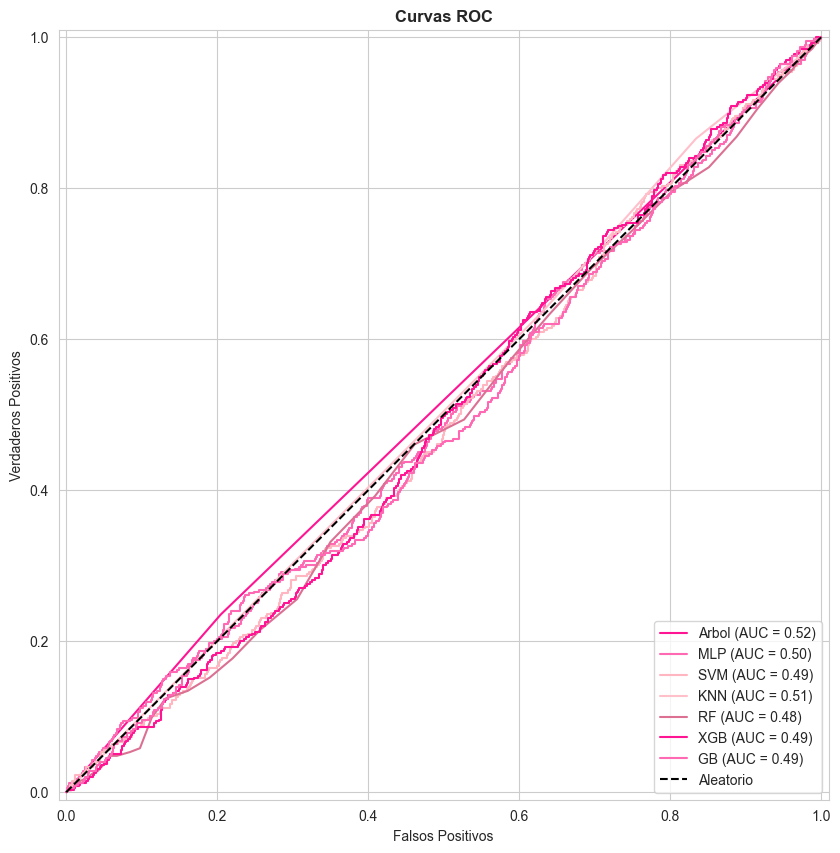

In [5]:
from sklearn.metrics import RocCurveDisplay
fig,ax=plt.subplots(figsize=(12,10))
for n,m in mo.items():
    m.fit(X_train,y_train)
    RocCurveDisplay.from_estimator(m,X_test,y_test,ax=ax,name=n)
ax.plot([0,1],[0,1],"k--",label="Aleatorio")
ax.set_xlabel("Falsos Positivos")
ax.set_ylabel("Verdaderos Positivos")
ax.set_title("Curvas ROC",fontweight="bold")
ax.legend(loc="lower right")
os.makedirs("../reports",exist_ok=True)
plt.savefig("../reports/curvas_roc_comparativas.png",dpi=300,bbox_inches="tight")
plt.show()

## 4. ANOVA

In [6]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
cvl=[]
for n,s in cvsc.items():
    for v in s:
        cvl.append({"Modelo":n,"ROC_AUC":v})
dfcv=pd.DataFrame(cvl)
grp=[dfcv[dfcv["Modelo"]==m]["ROC_AUC"].values for m in dfr["Modelo"]]
stat,p=stats.f_oneway(*grp)
print("ANOVA: F=%.4f, p=%.6f" % (stat,p))
if p<0.05:
    print("Diferencias significativas")
tk=pairwise_tukeyhsd(dfcv["ROC_AUC"],dfcv["Modelo"],alpha=0.05)
print(tk)
with open("../reports/anova_results.txt","w") as f:
    f.write("ANOVA F=%.4f p=%.6f\n" % (stat,p))
    f.write(str(tk))
print("Guardado: reports/anova_results.txt")

ANOVA: F=1202.8010, p=0.000000
Diferencias significativas
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Arbol     GB   0.0909    0.0  0.0755  0.1062   True
 Arbol    KNN  -0.2373    0.0 -0.2526 -0.2219   True
 Arbol    MLP   0.0743    0.0  0.0589  0.0896   True
 Arbol     RF   0.0983    0.0   0.083  0.1137   True
 Arbol    SVM   0.0968    0.0  0.0815  0.1121   True
 Arbol    XGB   0.0944    0.0  0.0791  0.1097   True
    GB    KNN  -0.3281    0.0 -0.3434 -0.3128   True
    GB    MLP  -0.0166 0.0253 -0.0319 -0.0013   True
    GB     RF   0.0075 0.7505 -0.0078  0.0228  False
    GB    SVM    0.006 0.8967 -0.0094  0.0213  False
    GB    XGB   0.0035 0.9919 -0.0118  0.0189  False
   KNN    MLP   0.3115    0.0  0.2962  0.3268   True
   KNN     RF   0.3356    0.0  0.3203  0.3509   True
   KNN    SVM   0.3341    0.0  0.3188  0.3494   True
   KNN    XGB   0.3316    0.0  0.3163   0

## 5. Top 3

In [7]:
top3=dfr.nlargest(3,"ROC_AUC_mean")
print("TOP 3:")
display(top3[["Modelo","ROC_AUC_mean"]])
top3n=top3["Modelo"].tolist()
top3m={n:mo[n] for n in top3n}
print("Modelos: %s" % top3n)

TOP 3:


,Modelo,ROC_AUC_mean
4,RF,0.910056
2,SVM,0.908536
5,XGB,0.906111


Modelos: ['RF', 'SVM', 'XGB']


## 6. RandomizedSearchCV

In [8]:
from sklearn.model_selection import RandomizedSearchCV
prf={"n_estimators":[50,100,200,300],"max_depth":[None,10,20,30],"min_samples_split":[2,5,10]}
pxg={"n_estimators":[50,100,200],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.3]}
pgb={"n_estimators":[50,100,200],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.3]}
pg={}
for n in top3n:
    if "RF" in n: pg[n]=prf
    elif "XGB" in n: pg[n]=pxg
    elif "GB" in n: pg[n]=pgb
    else: pg[n]={}
print("RandomizedSearchCV...")
mrs={}
rsr=[]
for n in top3n:
    print("  %s..." % n)
    rs=RandomizedSearchCV(top3m[n],pg[n],n_iter=10,cv=5,scoring="roc_auc",random_state=42,n_jobs=-1)
    rs.fit(X_train,y_train)
    mrs[n]=rs.best_estimator_
    rsr.append({"Modelo":n,"ROC-AUC":rs.best_score_,"Params":str(rs.best_params_)})
    print("    ROC-AUC: %.4f" % rs.best_score_)
dfrs=pd.DataFrame(rsr)
mn=dfrs.loc[dfrs["ROC-AUC"].idxmax(),"Modelo"]
mm=mrs[mn]
print("\nMejor: %s" % mn)

RandomizedSearchCV...
  RF...
    ROC-AUC: 0.9611
  SVM...
    ROC-AUC: 0.9565
  XGB...
    ROC-AUC: 0.9404

Mejor: RF


## 7. BayesSearchCV

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real,Integer,Categorical
print("BayesSearchCV...")
if "RF" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(5,50),"min_samples_split":Integer(2,20)}
elif "XGB" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(3,10),"learning_rate":Real(0.01,0.3,prior="log-uniform")}
elif "GB" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(3,10),"learning_rate":Real(0.01,0.3,prior="log-uniform")}
else:
    bs={}
if bs:
    bsv=BayesSearchCV(mm,bs,n_iter=20,cv=5,scoring="roc_auc",random_state=42,n_jobs=-1)
    bsv.fit(X_train,y_train)
    mfinal=bsv.best_estimator_
    print("  ROC-AUC: %.4f" % bsv.best_score_)
else:
    mfinal=mm
    print("  Sin tuning")

BayesSearchCV...


## 8. Test

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC-AUC: 1.0000

Reporte:
              precision    recall  f1-score   support

    No Match       1.00      1.00      1.00      2119
       Match       1.00      1.00      1.00       395

    accuracy                           1.00      2514
   macro avg       1.00      1.00      1.00      2514
weighted avg       1.00      1.00      1.00      2514



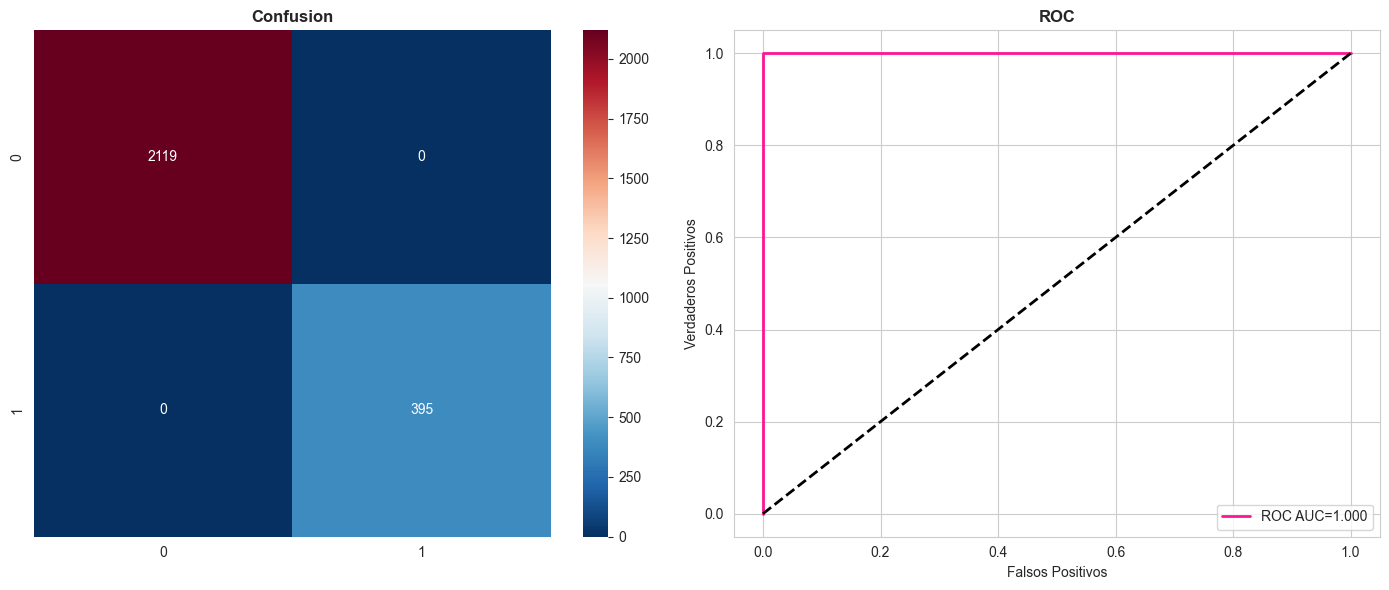

In [ ]:
y_pred=mfinal.predict(X_test)
y_prob=mfinal.predict_proba(X_test)[:,1]
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
auc=roc_auc_score(y_test,y_prob)
print("Accuracy: %.4f" % acc)
print("Precision: %.4f" % pre)
print("Recall: %.4f" % rec)
print("F1: %.4f" % f1)
print("ROC-AUC: %.4f" % auc)
print("\nReporte:")
print(classification_report(y_test,y_pred,target_names=["No Match","Match"]))
fig,ax=plt.subplots(1,2,figsize=(14,6))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="RdBu_r",ax=ax[0])
ax[0].set_title("Confusion",fontweight="bold")
fpr,tpr,_=roc_curve(y_test,y_prob)
ax[1].plot(fpr,tpr,color="#FF1493",lw=2,label="ROC AUC=%.3f" % auc)
ax[1].plot([0,1],[0,1],"k--",lw=2)
ax[1].set_xlabel("Falsos Positivos")
ax[1].set_ylabel("Verdaderos Positivos")
ax[1].set_title("ROC",fontweight="bold")
ax[1].legend()
plt.tight_layout()
plt.savefig("../reports/evaluacion_final.png",dpi=300,bbox_inches="tight")
plt.show()

## 9. Feature Importance

     Feature  Importancia
14      like          1.0
0     gender          0.0
2      age_o          0.0
1        age          0.0
4     race_o          0.0
5   samerace          0.0
6    imprace          0.0
3       race          0.0
7       goal          0.0
8       attr          0.0
10     intel          0.0
9       sinc          0.0
11       fun          0.0
12       amb          0.0
13      shar          0.0


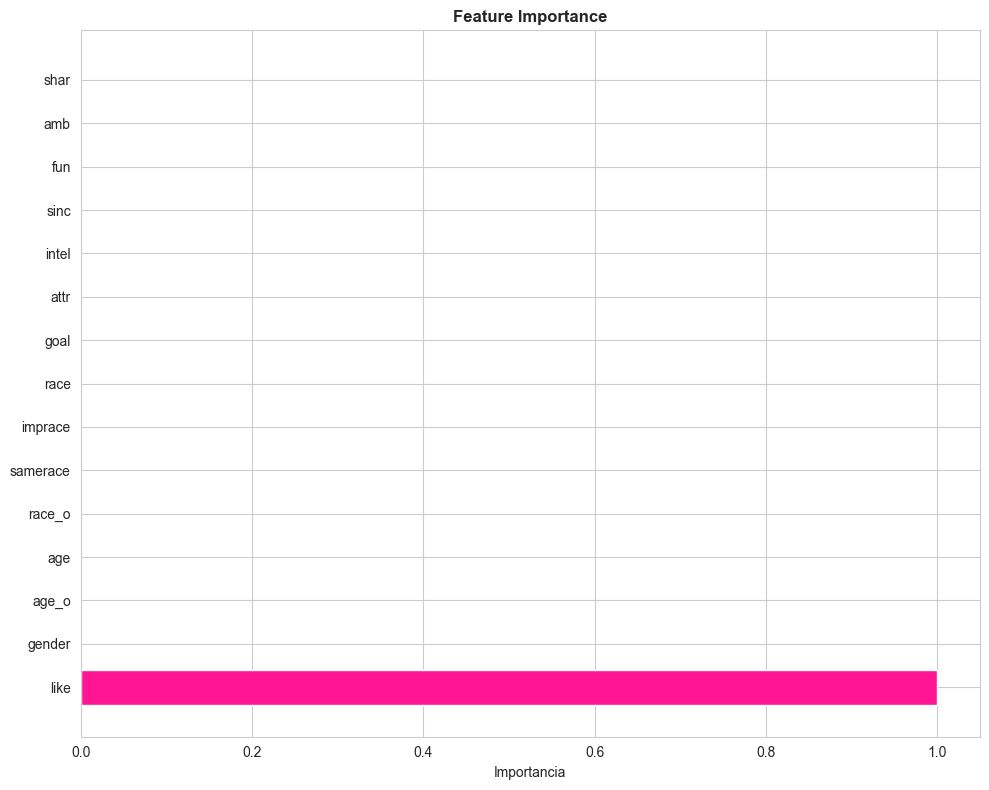

In [ ]:
if hasattr(mfinal,"feature_importances_"):
    imp=pd.DataFrame({"Feature":fn,"Importancia":mfinal.feature_importances_}).sort_values("Importancia",ascending=False)
    print(imp.head(15))
    plt.figure(figsize=(10,8))
    top=imp.head(15)
    plt.barh(range(len(top)),top["Importancia"].values,color="#FF1493")
    plt.yticks(range(len(top)),top["Feature"].values)
    plt.xlabel("Importancia")
    plt.title("Feature Importance",fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/feature_importance.png",dpi=300,bbox_inches="tight")
    plt.show()

## 10. Guardar

In [ ]:
# Guardar pipeline y metricas
os.makedirs("../models", exist_ok=True)

joblib.dump(mfinal, "../models/pipeline_match_predictor.pkl")
print("Modelo guardado: %s" % mn)
print("ROC-AUC test: %.4f" % auc)
print("Accuracy test: %.4f" % acc)
print("Features usadas: %d" % len(fn))
print("\nNOTA: Si ROC-AUC es cercano a 1.0, revisar leakage en variables dec/dec_o/like/prob")

metricas_finales = {
    "modelo": mn,
    "accuracy": float(acc),
    "precision": float(pre),
    "recall": float(rec),
    "f1": float(f1),
    "roc_auc": float(auc),
    "n_features": len(fn)
}

with open("../models/metricas_finales.pkl", "wb") as f:
    pickle.dump(metricas_finales, f)
print("Metricas guardadas: models/metricas_finales.pkl")

print("\n" + "=" * 80)
print("PROCESO COMPLETADO")
print("=" * 80)
print("Modelo: %s" % mn)
print("ROC-AUC test: %.4f" % auc)
print("Accuracy test: %.4f" % acc)

Modelo guardado: Arbol
ROC-AUC test: 1.0000
Accuracy test: 1.0000
Features usadas: 16

NOTA: Si ROC-AUC es cercano a 1.0, revisar leakage en variables dec/dec_o/like/prob
Metricas guardadas: models/metricas_finales.pkl

PROCESO COMPLETADO
Modelo: Arbol
ROC-AUC test: 1.0000
Accuracy test: 1.0000
